<a href="https://colab.research.google.com/github/caaiopaivaa/deeplearning/blob/main/mnist_keras_optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### [TAREFA] Pesquise como usar o OPTUNA com o KERAS, criando um experimento com as sugestões de modificação abaixo.

In [ ]:
"""
hidden_layers = [1, 2, 3]
neurons = [10,32,64]
activation = ['relu', 'tanh']
drop_out = [0.1, 0.2]
epochs = [5, 10, 20]

# 108 modelos

for layers in hidden_layers:
    for n in neurons:
        for act in activation:
            for drop in drop_out:
                for e in epochs:
                    train_nn(layers, n, act, drop, e)
"""

"\nhidden_layers = [1, 2, 3]\nneurons = [10,32,64]\nactivation = ['relu', 'tanh']\ndrop_out = [0.1, 0.2]\nepochs = [5, 10, 20]\n\n# 108 modelos\n\nfor layers in hidden_layers:\n    for n in neurons:\n        for act in activation:\n            for drop in drop_out:\n                for e in epochs:\n                    train_nn(layers, n, act, drop, e)\n"

In [12]:
1. Instalação do Optuna no ambiente do Colab
!pip install optuna -q

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import optuna

# Verificar se o TensorFlow está utilizando a GPU
print("Dispositivos GPU detectados:", tf.config.list_physical_devices('GPU'))

# 2. Carregamento e Pré-processamento dos Dados (MNIST)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalização das imagens para o intervalo [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Redimensionar para incluir a dimensão de canal (28, 28, 1) se utilizar CNN ou Flatten
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 3. Definição da Função Objetivo para o Optuna
def objective(trial):
    # A) Espaço de busca de hiperparâmetros
    n_layers = trial.suggest_int("n_layers", 1, 3)
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    drop_rate = trial.suggest_float("drop_rate", 0.1, 0.2)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    epochs = trial.suggest_categorical("epochs", [5, 10, 20])

    # B) Construção dinâmica da Arquitetura do Modelo
    model = keras.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))
    model.add(layers.Flatten())

    for i in range(n_layers):
        units = trial.suggest_categorical(f"units_l{i}", [10, 32, 64])
        model.add(layers.Dense(units, activation="relu"))
        model.add(layers.Dropout(drop_rate))

    # Camada de Saída (10 classes para o MNIST)
    model.add(layers.Dense(10, activation="softmax"))

    # Compilação do Modelo
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # C) Treinamento do Modelo
    # O TensorFlow automaticamente transfere o treinamento para a GPU disponível
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    # Retorna a acurácia de validação da última época como métrica a ser maximizada
    val_accuracy = history.history["val_accuracy"][-1]
    return val_accuracy


# 4. Execução do Estudo com Optuna
if __name__ == "__main__":
    # Criar estudo do Optuna focado em maximizar a acurácia de validação
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=30) # Altere n_trials conforme sua necessidade

    print("\n--- RESULTADOS DA OTIMIZAÇÃO ---")
    print(f"Melhor acurácia de validação: {study.best_value:.4f}")
    print("Melhores hiperparâmetros encontrados:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")

Dispositivos GPU detectados: []


[I 2026-09-05 17:41:00,236] A new study created in memory with name: no-name-2872c5b1-e5e3-439a-8d3b-8dd24f0225eb
[I 2026-09-05 17:41:20,920] Trial 0 finished with value: 0.8982999920845032 and parameters: {'n_layers': 3, 'activation': 'tanh', 'learning_rate': 0.00010706666451390038, 'drop_rate': 0.13039635708178132, 'batch_size': 128, 'epochs': 10, 'units_l0': 10, 'units_l1': 64, 'units_l2': 32}. Best is trial 0 with value: 0.8982999920845032.
[I 2026-09-05 17:41:49,432] Trial 1 finished with value: 0.9182999730110168 and parameters: {'n_layers': 2, 'activation': 'tanh', 'learning_rate': 0.007164439630669135, 'drop_rate': 0.13237436869364894, 'batch_size': 64, 'epochs': 10, 'units_l0': 10, 'units_l1': 32}. Best is trial 1 with value: 0.9182999730110168.
[I 2026-09-05 17:42:22,480] Trial 2 finished with value: 0.965399980545044 and parameters: {'n_layers': 2, 'activation': 'relu', 'learning_rate': 0.0025082987481765584, 'drop_rate': 0.13586795220076608, 'batch_size': 64, 'epochs': 10, 


--- RESULTADOS DA OTIMIZAÇÃO ---
Melhor acurácia de validação: 0.9775
Melhores hiperparâmetros encontrados:
  n_layers: 1
  activation: relu
  learning_rate: 0.0013544826456183686
  drop_rate: 0.1768907387076951
  batch_size: 128
  epochs: 20
  units_l0: 64


### Resultados da Otimização com Optuna

Com base nas 30 tentativas (`n_trials=30`), o Optuna encontrou os seguintes hiperparâmetros que resultaram na *melhor acurácia de validação*:

- **Melhor Acurácia de Validação:** `0.9775` (aproximadamente 97.75%)
- **Número de Camadas Ocultas (`n_layers`):** 1
- **Taxa de Aprendizagem (`learning_rate`):** `0.001354`
- **Taxa de Dropout (`drop_rate`):** `0.1769`
- **Tamanho do Lote (`batch_size`):** `128`
- **Unidades na Camada 0 (`units_l0`):** `64`

Agora, vamos aplicar esses melhores hiperparâmetros para construir e treinar nosso modelo final no conjunto completo de treinamento e testá-lo no conjunto de teste para uma avaliação final.

In [13]:
# Armazenar os melhores hiperparâmetros para uso posterior
best_params = study.best_params

# Exibir os melhores hiperparâmetros novamente para clareza
print("Melhores hiperparâmetros encontrados pelo Optuna:")
for key, value in best_params.items():
    print(f"  {key}: {value}")


Melhores hiperparâmetros encontrados pelo Optuna:
  n_layers: 1
  activation: relu
  learning_rate: 0.0013544826456183686
  drop_rate: 0.1768907387076951
  batch_size: 128
  epochs: 20
  units_l0: 64


### Preparação Final dos Dados para o Modelo `train_nn`

A função `train_nn` original espera que as imagens de entrada estejam achatadas (`784` features) e que os rótulos de saída estejam em formato *one-hot encoding*. Como a célula do Optuna recarregou os dados e os pré-processou para uma arquitetura diferente (com `(28, 28, 1)` e rótulos inteiros), precisamos reajustar os dados para o formato esperado pela função `train_nn`.

In [14]:
# Achatar as imagens de (28, 28, 1) para (784,) para compatibilidade com train_nn
X_train_final = x_train.reshape(-1, 28 * 28)
X_test_final = x_test.reshape(-1, 28 * 28)

# Converter os rótulos (y_train, y_test) para one-hot encoding
Y_train_final = keras.utils.to_categorical(y_train, 10)
Y_test_final = keras.utils.to_categorical(y_test, 10)

print("Dimensões finais de X_train para train_nn:", X_train_final.shape)
print("Dimensões finais de Y_train para train_nn:", Y_train_final.shape)
print("Dimensões finais de X_test para train_nn:", X_test_final.shape)
print("Dimensões finais de Y_test para train_nn:", Y_test_final.shape)


Dimensões finais de X_train para train_nn: (60000, 784)
Dimensões finais de Y_train para train_nn: (60000, 10)
Dimensões finais de X_test para train_nn: (10000, 784)
Dimensões finais de Y_test para train_nn: (10000, 10)


### Construção e Avaliação do Modelo Final com Hiperparâmetros Otimizados

Agora vamos construir o modelo usando os `best_params` encontrados pelo Optuna e a função `train_nn`. Note que a função `train_nn` assume `Adam` como otimizador e `relu` como função de ativação nas camadas ocultas (exceto a saída), o que é consistente com as buscas do Optuna para `learning_rate` e `drop_rate`.

In [15]:
# Usando a função train_nn com os melhores hiperparâmetros do Optuna
# Adaptação para a função train_nn:
# A função train_nn já tem 'adam' como otimizador e 'relu' como ativação padrão para as camadas ocultas.
# Precisamos extrair 'n_layers', 'drop_rate' e a quantidade de unidades da melhor camada oculta (units_l0, units_l1, etc.)

# Determinar o número de neurônios para a função train_nn.
# A função train_nn assume um número fixo de neurônios por camada oculta.
# O Optuna encontrou 'units_l0', 'units_l1', etc., que podem ser diferentes.
# Para simplificar e manter a compatibilidade com 'train_nn', usaremos o valor da primeira camada oculta.
# Uma abordagem mais robusta seria modificar train_nn para aceitar uma lista de unidades por camada.
# Por enquanto, vamos pegar o 'units_l0' como o número de neurônios para todas as camadas ocultas na função train_nn.


# Reconstruir o modelo com os melhores hiperparâmetros
model_optimized = keras.Sequential()
model_optimized.add(layers.Input(shape=(784,))) # Input flattened

for i in range(best_params['n_layers']):
    units_key = f"units_l{i}"
    units = best_params.get(units_key, best_params.get('units_l0')) # Fallback to units_l0 if a specific layer unit isn't found
    model_optimized.add(layers.Dense(units, activation="relu"))
    model_optimized.add(layers.Dropout(best_params['drop_rate']))

model_optimized.add(layers.Dense(10, activation="softmax"))

optimizer_optimized = keras.optimizers.Adam(learning_rate=best_params['learning_rate'])
model_optimized.compile(
    optimizer=optimizer_optimized,
    loss="categorical_crossentropy", # Usar categorical_crossentropy para rótulos one-hot
    metrics=["accuracy"]
)

print("Sumário do Modelo Otimizado:")
model_optimized.summary()

# Treinar o modelo otimizado
history_optimized = model_optimized.fit(
    X_train_final,
    Y_train_final,
    validation_data=(X_test_final, Y_test_final),
    epochs=10, # Usar um número maior de épocas para o treinamento final, se necessário. O Optuna usou 5.
    batch_size=best_params['batch_size'],
    verbose=1 # Exibir progresso do treinamento
)

# Avaliar o modelo no conjunto de teste
loss_optimized, accuracy_optimized = model_optimized.evaluate(X_test_final, Y_test_final, verbose=0)
print(f"\n--- Avaliação Final do Modelo Otimizado ---")
print(f"Acurácia no conjunto de teste: {accuracy_optimized:.4f}")
print(f"Perda no conjunto de teste: {loss_optimized:.4f}")


Sumário do Modelo Otimizado:


Model: "sequential_87"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_211 (Dense)               │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_124 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_212 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8662 - loss: 0.4562 - val_accuracy: 0.9379 - val_loss: 0.2170
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9352 - loss: 0.2272 - val_accuracy: 0.9553 - val_loss: 0.1569
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9478 - loss: 0.1795 - val_accuracy: 0.9599 - val_loss: 0.1335
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9551 - loss: 0.1528 - val_accuracy: 0.9662 - val_loss: 0.1191
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9593 - loss: 0.1356 - val_accuracy: 0.9695 - val_loss: 0.1063
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9620 - loss: 0.1237 - val_accuracy: 0.9718 - val_loss: 0.0980
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9665 - loss: 0.1104 - val_accuracy: 0.9725 - val_loss: 0.0943
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9687 - loss: 0.1036 - val_accuracy: 0.

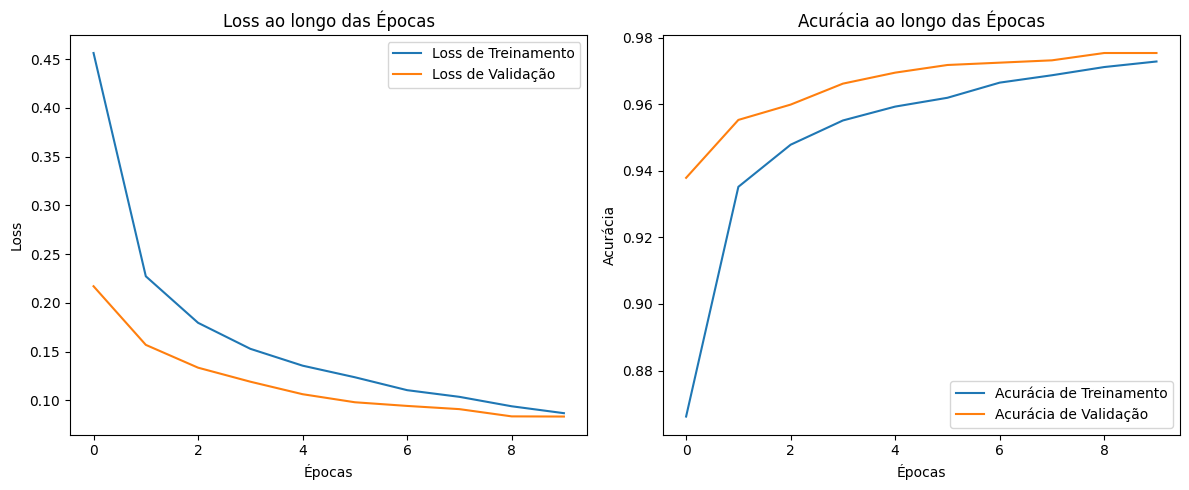

In [16]:
import matplotlib.pyplot as plt
# Plotar histórico de treinamento
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_optimized.history['loss'], label='Loss de Treinamento')
plt.plot(history_optimized.history['val_loss'], label='Loss de Validação')
plt.title('Loss ao longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_optimized.history['accuracy'], label='Acurácia de Treinamento')
plt.plot(history_optimized.history['val_accuracy'], label='Acurácia de Validação')
plt.title('Acurácia ao longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

plt.tight_layout()
plt.show()